<a href="https://colab.research.google.com/github/HakumenWorld/data-science-2026/blob/main/Pertemuan10_Febi_Kristiana_240401010231.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Pertemuan 10 — Algoritma Klasifikasi
# Aktivitas Hands-on: Customer Churn
**Mata Kuliah:** Pengantar Data Science  
**Pertemuan:** 10  
**Nama:** Febi Kristiana  
**NIM:** 240401010231

Notebook ini disusun mengikuti bagian **Aktivitas Hands-on** pada modul pertemuan 10.  
Jalankan sel secara berurutan dari atas ke bawah di Google Colab.

## 1. Load Dataset dan EDA Singkat

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.datasets import load_breast_cancer

data = load_breast_cancer()
X = pd.DataFrame(data.data, columns=data.feature_names)
y = data.target  # 0 = Malignant, 1 = Benign

print("Shape dataset:", X.shape)
print("\nDistribusi target:")
distribusi = pd.Series(y).map({0: "Malignant", 1: "Benign"}).value_counts()
print(distribusi)

display(X.head())

Shape dataset: (569, 30)

Distribusi target:
Benign       357
Malignant    212
Name: count, dtype: int64


,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst radius,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension
0,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,0.07871,...,25.38,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890
1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,0.05667,...,24.99,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902
2,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,0.05999,...,23.57,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758
3,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,0.09744,...,14.91,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300
4,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,0.05883,...,22.54,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678


## 2. Preprocessing: Train-Test Split dan StandardScaler

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("Data train:", X_train.shape)
print("Data test :", X_test.shape)

Data train: (455, 30)
Data test : (114, 30)


## 3. Logistic Regression

In [ ]:
from sklearn.linear_model import LogisticRegression

log_model = LogisticRegression(max_iter=5000, random_state=42)
log_model.fit(X_train_scaled, y_train)
y_pred_log = log_model.predict(X_test_scaled)

print("Logistic Regression selesai dilatih.")

Logistic Regression selesai dilatih.


## 4. Decision Tree

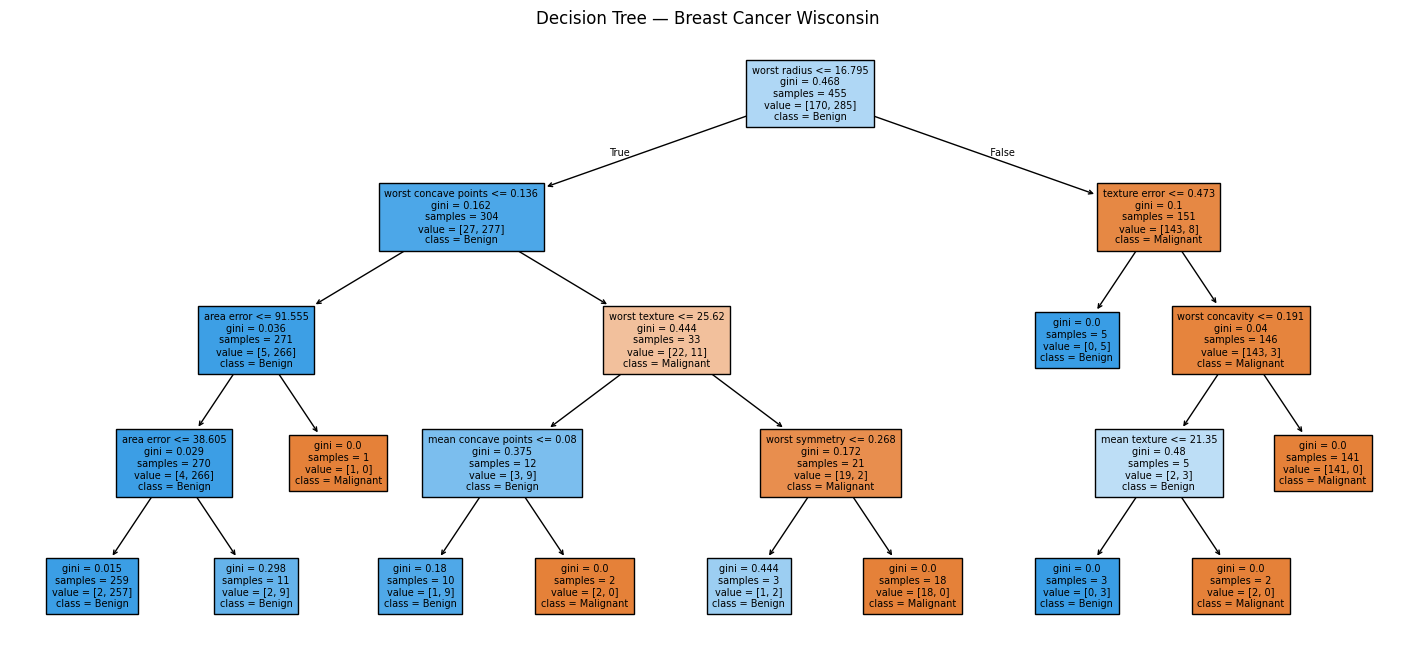

In [ ]:
from sklearn.tree import DecisionTreeClassifier, plot_tree

tree_model = DecisionTreeClassifier(
    max_depth=4,
    random_state=42
)
tree_model.fit(X_train, y_train)
y_pred_tree = tree_model.predict(X_test)

plt.figure(figsize=(18, 8))
plot_tree(
    tree_model,
    feature_names=X.columns,
    class_names=["Malignant", "Benign"],
    filled=True,
    fontsize=7
)
plt.title("Decision Tree — Breast Cancer Wisconsin")
plt.show()

## 5. Evaluasi WAJIB: Confusion Matrix + Accuracy, Precision, Recall, F1-Score

**Catatan penting:** pada dataset ini `0 = Malignant` dan `1 = Benign`.  
Karena konteksnya diagnosis kanker, metrik Precision, Recall, dan F1-Score di bawah dihitung dengan
**Malignant sebagai kelas positif (`pos_label=0`)**. Dengan demikian Recall benar-benar menunjukkan
seberapa banyak kasus kanker yang berhasil ditemukan model.

Logistic Regression


,Prediksi Malignant,Prediksi Benign
Aktual Malignant,41,1
Aktual Benign,1,71


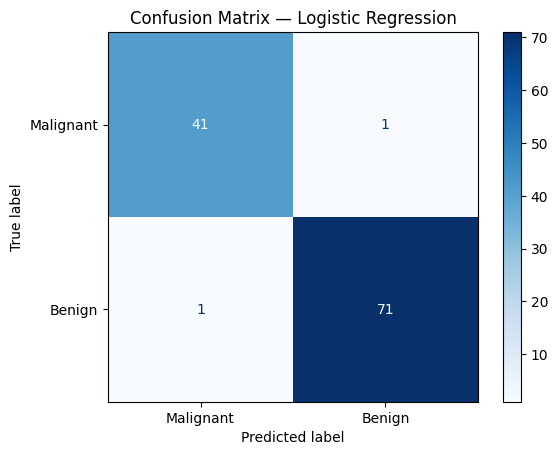

Decision Tree


,Prediksi Malignant,Prediksi Benign
Aktual Malignant,39,3
Aktual Benign,4,68


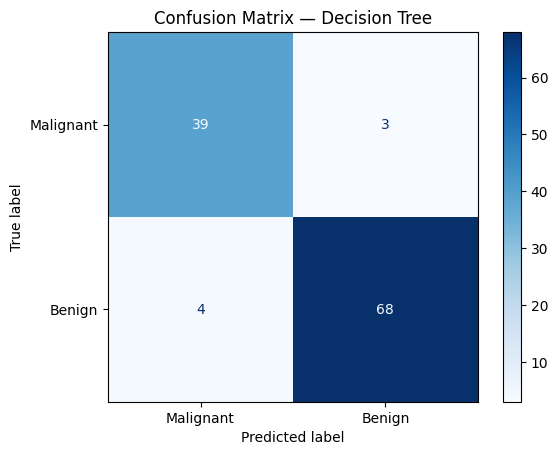


RINGKASAN METRIK:


,Accuracy,Precision (Malignant),Recall (Malignant),F1-Score (Malignant)
Model,,,,
Logistic Regression,0.9825,0.9762,0.9762,0.9762
Decision Tree,0.9386,0.9070,0.9286,0.9176


In [ ]:
from sklearn.metrics import (
    confusion_matrix, ConfusionMatrixDisplay,
    accuracy_score, precision_score, recall_score, f1_score
)

models = {
    "Logistic Regression": y_pred_log,
    "Decision Tree": y_pred_tree
}

hasil = []

for nama_model, y_pred in models.items():
    cm = confusion_matrix(y_test, y_pred, labels=[0, 1])

    print("=" * 65)
    print(nama_model)
    print("=" * 65)

    # Tabel Confusion Matrix
    cm_df = pd.DataFrame(
        cm,
        index=["Aktual Malignant", "Aktual Benign"],
        columns=["Prediksi Malignant", "Prediksi Benign"]
    )
    display(cm_df)

    # Heatmap menggunakan ConfusionMatrixDisplay
    disp = ConfusionMatrixDisplay(
        confusion_matrix=cm,
        display_labels=["Malignant", "Benign"]
    )
    disp.plot(cmap="Blues", values_format="d")
    plt.title(f"Confusion Matrix — {nama_model}")
    plt.show()

    accuracy = accuracy_score(y_test, y_pred)
    precision = precision_score(y_test, y_pred, pos_label=0)
    recall = recall_score(y_test, y_pred, pos_label=0)
    f1 = f1_score(y_test, y_pred, pos_label=0)

    hasil.append({
        "Model": nama_model,
        "Accuracy": accuracy,
        "Precision (Malignant)": precision,
        "Recall (Malignant)": recall,
        "F1-Score (Malignant)": f1
    })

hasil_df = pd.DataFrame(hasil).set_index("Model")

print("\nRINGKASAN METRIK:")
display(hasil_df.round(4))

## 6. Interpretasi Metrik

In [ ]:
model_recall_terbaik = hasil_df["Recall (Malignant)"].idxmax()
recall_terbaik = hasil_df.loc[model_recall_terbaik, "Recall (Malignant)"]

print(
    f"Model dengan Recall Malignant tertinggi adalah {model_recall_terbaik} "
    f"dengan nilai {recall_terbaik:.4f}."
)

print(
    "\nInterpretasi:\n"
    "- Accuracy menunjukkan proporsi seluruh prediksi yang benar, tetapi bukan satu-satunya metrik penting.\n"
    "- Precision Malignant menunjukkan seberapa banyak prediksi kanker yang benar-benar kanker.\n"
    "- Recall Malignant menunjukkan seberapa banyak pasien kanker yang berhasil terdeteksi.\n"
    "- F1-Score menyeimbangkan Precision dan Recall.\n\n"
    "Untuk kasus diagnosis kanker, RECALL MALIGNANT merupakan metrik yang sangat penting "
    "karena False Negative berarti pasien yang sebenarnya kanker diprediksi sebagai benign. "
    "Kesalahan seperti ini berisiko membuat kasus kanker terlewat."
)

Model dengan Recall Malignant tertinggi adalah Logistic Regression dengan nilai 0.9762.

Interpretasi:
- Accuracy menunjukkan proporsi seluruh prediksi yang benar, tetapi bukan satu-satunya metrik penting.
- Precision Malignant menunjukkan seberapa banyak prediksi kanker yang benar-benar kanker.
- Recall Malignant menunjukkan seberapa banyak pasien kanker yang berhasil terdeteksi.
- F1-Score menyeimbangkan Precision dan Recall.

Untuk kasus diagnosis kanker, RECALL MALIGNANT merupakan metrik yang sangat penting karena False Negative berarti pasien yang sebenarnya kanker diprediksi sebagai benign. Kesalahan seperti ini berisiko membuat kasus kanker terlewat.


## Kesimpulan

Logistic Regression dan Decision Tree dapat digunakan untuk menyelesaikan kasus klasifikasi diagnosis.
Namun, pemilihan model tidak sebaiknya hanya berdasarkan Accuracy. Untuk kasus medis seperti deteksi kanker,
**Recall pada kelas Malignant lebih relevan** karena tujuan pentingnya adalah menekan *False Negative*,
yaitu pasien kanker yang tidak berhasil terdeteksi.

Setelah notebook dijalankan, gunakan tabel ringkasan metrik untuk menentukan model yang paling baik,
khususnya dengan melihat **Recall Malignant** dan kemudian mempertimbangkan Precision serta F1-Score
sebagai metrik pendukung.